# Анализ сжатия данных методом PCA

Этот ноутбук предназначен для:
- Сжатия данных концентрации CO с помощью PCA
- Анализа качества реконструкции
- Сравнения с автоэнкодером
- Подбора оптимального количества компонент

In [1]:
cd ..

/home/jupyter-polyakov1337_2026/science/co_autoencoder_project


/opt/tljh/user/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.insert(0, 'src')

from src.data import load_data, normalize_data
from src.pca import PCACompressor, analyze_pca_components
from src.models import Conv3DAutoencoder
from src.train import load_model, WeightedHeightLoss
from src.data import load_data, normalize_data, ConcentrationFieldDataset
from tqdm import tqdm
%matplotlib inline

In [10]:
from sklearn.model_selection import train_test_split


## Загрузка данных

In [11]:
# Список всех файлов (как в config.yaml)
ALL_FILES = [
    '../OUTPUT/Nsk_2024-07-01_00_00_to_2024-07-02_00_00/all_sources/uvwmn_d03_2024-07-01_00:00:00_n33_chem_13.nc',
    '../OUTPUT/Nsk_2024-07-13_00_00_to_2024-07-14_00_00/all_sources/uvwmn_d03_2024-07-13_00:00:00_n33_chem_13.nc',
    '../OUTPUT/Nsk_2024-07-28_00_00_to_2024-07-29_00_00/all_sources/uvwmn_d03_2024-07-28_00:00:00_n33_chem_13.nc',
    '../OUTPUT/Nsk_2024-08-05_00_00_to_2024-08-06_00_00/all_sources/uvwmn_d03_2024-08-05_00:00:00_n33_chem_13.nc',
    '../OUTPUT/Nsk_2024-08-26_00_00_to_2024-08-27_00_00/all_sources/uvwmn_d03_2024-08-26_00:00:00_n33_chem_13.nc',
    '../OUTPUT/Nsk_2024-09-05_00_00_to_2024-09-06_00_00/all_sources/uvwmn_d03_2024-09-05_00:00:00_n33_chem_13.nc',
    '../OUTPUT/Nsk_2024-09-12_00_00_to_2024-09-13_00_00/all_sources/uvwmn_d03_2024-09-12_00:00:00_n33_chem_13.nc',
    '../OUTPUT/Nsk_2025-04-29_00_00_to_2025-04-30_00_00/all_sources/uvwmn_d03_2025-04-29_00:00:00_n33_chem_13.nc',
    '../OUTPUT/Nsk_2025-05-09_00_00_to_2025-05-10_00_00/all_sources/uvwmn_d03_2025-05-09_00:00:00_n33_chem_13.nc',
    '../OUTPUT/Nsk_2025-05-15_00_00_to_2025-05-16_00_00/all_sources/uvwmn_d03_2025-05-15_00:00:00_n33_chem_13.nc',
    '../OUTPUT/Nsk_2025-06-18_00_00_to_2025-06-19_00_00/all_sources/uvwmn_d03_2025-06-18_00:00:00_n33_chem_13.nc',
]

# Параметры (должны совпадать с config.yaml)
VAL_SPLIT = 0.10
RANDOM_SEED = 42

# Загружаем все данные
print("Загрузка всех данных...")
all_data = load_data(ALL_FILES, base_dir='')
all_normalized = normalize_data(all_data)

print(f"Объединенные данные: {all_normalized.shape}")
print(f"Нормализованные данные: min={all_normalized.min():.4f}, max={all_normalized.max():.4f}")

print(f"\nВсего кадров: {len(all_normalized)}")

# Случайное разбиение (как при обучении!)
indices = list(range(len(all_normalized)))
train_indices, val_indices = train_test_split(
    indices, 
    test_size=VAL_SPLIT, 
    random_state=RANDOM_SEED
)

# Создаем датасеты
full_dataset = ConcentrationFieldDataset(all_normalized)
train_dataset = torch.utils.data.Subset(full_dataset, train_indices)
val_dataset = torch.utils.data.Subset(full_dataset, val_indices)

print(f"\nTrain выборка: {len(train_dataset)} кадров ({len(train_indices)/len(indices)*100:.1f}%)")
print(f"Валидационная выборка: {len(val_dataset)} кадров ({len(val_indices)/len(indices)*100:.1f}%)")
print(f"random_state={RANDOM_SEED}, val_split={VAL_SPLIT}")

# Получаем данные для обучения PCA (train) и валидации (val)
train_data = all_normalized[train_indices]
val_data = all_normalized[val_indices]

print(f"\nTrain данные: {train_data.shape}")
print(f"Val данные: {val_data.shape}")

Загрузка всех данных...


Загрузка файлов: 100%|██████████| 11/11 [00:06<00:00,  1.74it/s]


Объединенные данные: (1595, 32, 96, 84)
Нормализованные данные: min=0.0000, max=1.0000
Объединенные данные: (1595, 32, 96, 84)
Нормализованные данные: min=0.0000, max=1.0000

Всего кадров: 1595

Train выборка: 1435 кадров (90.0%)
Валидационная выборка: 160 кадров (10.0%)
random_state=42, val_split=0.1

Train данные: (1435, 32, 96, 84)
Val данные: (160, 32, 96, 84)


## Анализ PCA с разным количеством компонент

In [12]:
N_COMPONENTS = [8, 16, 32, 64, 128, 256, 512]
verbose = True

print("Анализ PCA с разным количеством компонент...\n")
print("PCA обучается на train данных, оценка на val данных\n")

results = {}

for n_comp in tqdm(N_COMPONENTS, desc="Анализ PCA"):
    # Создаем и обучаем PCA на train данных
    compressor = PCACompressor(n_components=n_comp)
    compressor.fit(train_data, verbose=False)
    
    # Оцениваем на val данных
    compressed = compressor.transform(val_data)
    reconstructed = compressor.reconstruct(compressed)
    
    # Вычисляем метрики на val
    mse = np.mean((val_data - reconstructed) ** 2)
    mae = np.mean(np.abs(val_data - reconstructed))
    var_ratio = compressor.explained_variance_ratio().sum()
    
    results[n_comp] = {
        'mse': mse,
        'mae': mae,
        'explained_variance': var_ratio,
        'compression_ratio': val_data[0].size / n_comp,
        'compressor': compressor
    }
    
    if verbose:
        print(f"\nn_components={n_comp}:")
        print(f"  MSE: {mse:.6f}")
        print(f"  MAE: {mae:.6f}")
        print(f"  Объяснённая дисперсия: {var_ratio:.4f}")
        print(f"  Коэффициент сжатия: {val_data[0].size / n_comp:.1f}x")

Анализ PCA с разным количеством компонент...

PCA обучается на train данных, оценка на val данных



Анализ PCA:  14%|█▍        | 1/7 [00:05<00:33,  5.51s/it]


n_components=8:
  MSE: 0.033298
  MAE: 0.141181
  Объяснённая дисперсия: 0.4500
  Коэффициент сжатия: 32256.0x


Анализ PCA:  29%|██▊       | 2/7 [00:11<00:28,  5.73s/it]


n_components=16:
  MSE: 0.024080
  MAE: 0.117779
  Объяснённая дисперсия: 0.6127
  Коэффициент сжатия: 16128.0x


...


n_components=128:
  MSE: 0.004528
  MAE: 0.045767
  Объяснённая дисперсия: 0.9465
  Коэффициент сжатия: 2016.0x


Анализ PCA:  86%|████████▌ | 6/7 [00:48<00:09,  9.57s/it]


n_components=256:
  MSE: 0.002539
  MAE: 0.032050
  Объяснённая дисперсия: 0.9788
  Коэффициент сжатия: 1008.0x


Анализ PCA: 100%|██████████| 7/7 [01:10<00:00, 10.03s/it]


n_components=512:
  MSE: 0.001567
  MAE: 0.022616
  Объяснённая дисперсия: 0.9943
  Коэффициент сжатия: 504.0x


## Визуализация результатов PCA

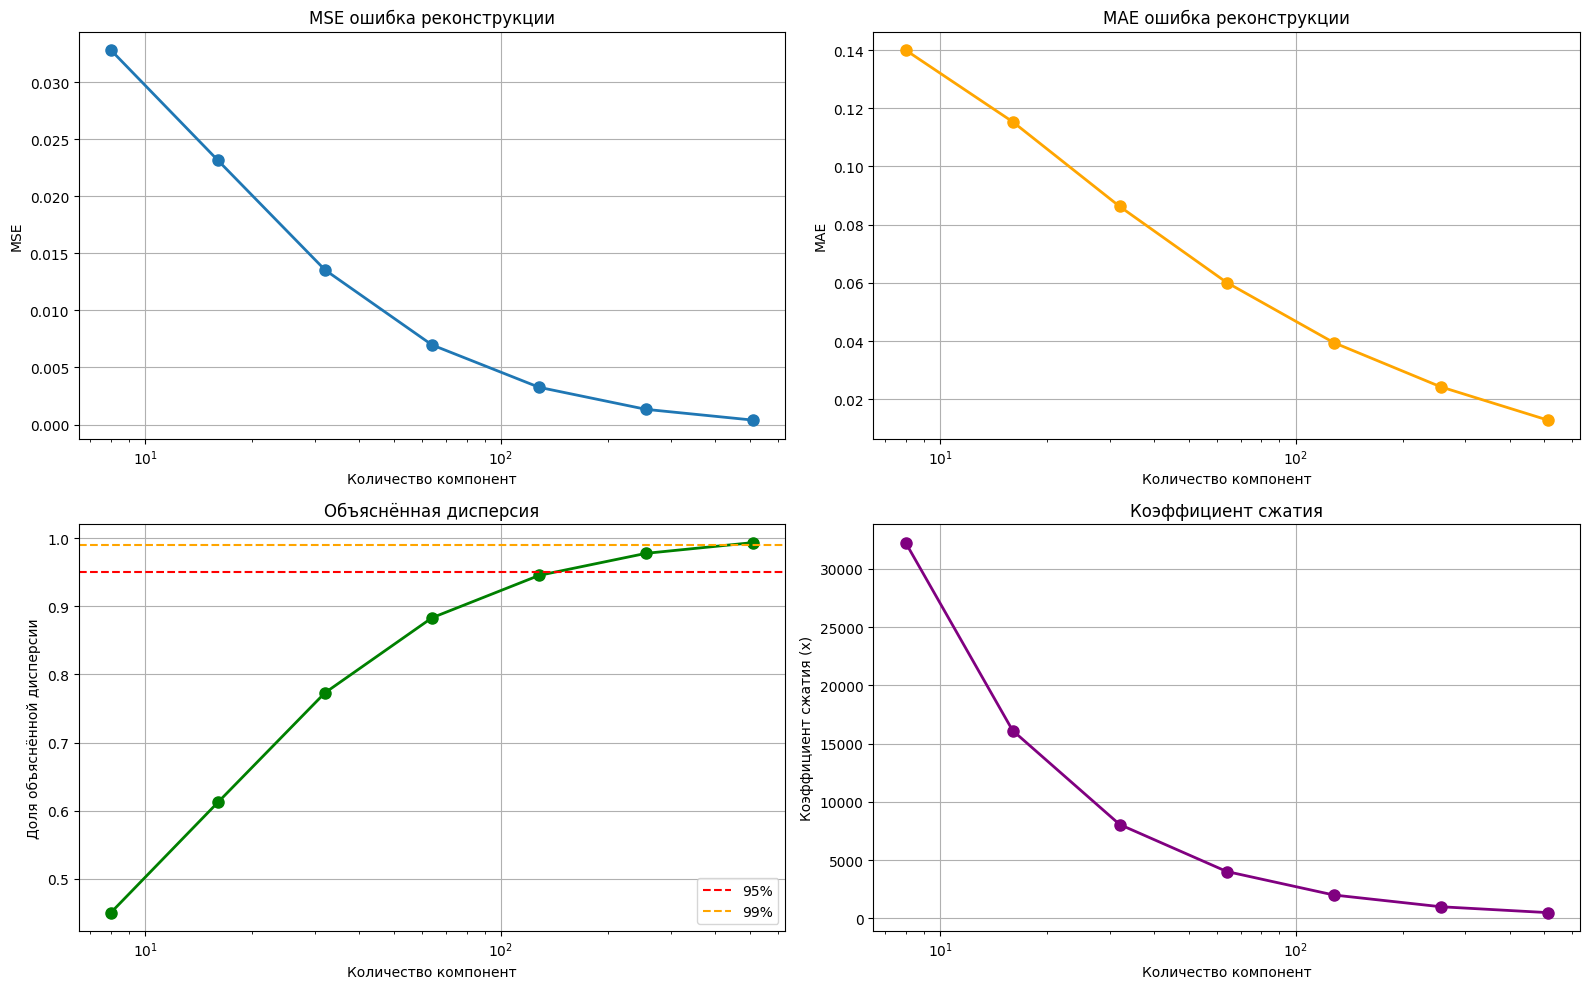


СВОДНАЯ ТАБЛИЦА
  Компоненты |        MSE |        MAE |      Var |   Сжатие
----------------------------------------------------------------------
           8 |   0.032799 |   0.139980 |   0.4506 |  32256.0x
          16 |   0.023136 |   0.115350 |   0.6125 |  16128.0x
          32 |   0.013543 |   0.086230 |   0.7732 |   8064.0x
          64 |   0.006972 |   0.060102 |   0.8832 |   4032.0x
         128 |   0.003261 |   0.039441 |   0.9454 |   2016.0x
         256 |   0.001328 |   0.024241 |   0.9778 |   1008.0x
         512 |   0.000387 |   0.012813 |   0.9935 |    504.0x


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

mse_values = [results[n]['mse'] for n in N_COMPONENTS]
axes[0, 0].plot(N_COMPONENTS, mse_values, 'o-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Количество компонент')
axes[0, 0].set_ylabel('MSE')
axes[0, 0].set_title('MSE ошибка реконструкции')
axes[0, 0].grid(True)
axes[0, 0].set_xscale('log')

mae_values = [results[n]['mae'] for n in N_COMPONENTS]
axes[0, 1].plot(N_COMPONENTS, mae_values, 'o-', linewidth=2, markersize=8, color='orange')
axes[0, 1].set_xlabel('Количество компонент')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].set_title('MAE ошибка реконструкции')
axes[0, 1].grid(True)
axes[0, 1].set_xscale('log')

var_values = [results[n]['explained_variance'] for n in N_COMPONENTS]
axes[1, 0].plot(N_COMPONENTS, var_values, 'o-', linewidth=2, markersize=8, color='green')
axes[1, 0].set_xlabel('Количество компонент')
axes[1, 0].set_ylabel('Доля объяснённой дисперсии')
axes[1, 0].set_title('Объяснённая дисперсия')
axes[1, 0].grid(True)
axes[1, 0].set_xscale('log')
axes[1, 0].axhline(y=0.95, color='r', linestyle='--', label='95%')
axes[1, 0].axhline(y=0.99, color='orange', linestyle='--', label='99%')
axes[1, 0].legend()

original_size = all_normalized[0].size
compression_ratios = [original_size / n for n in N_COMPONENTS]
axes[1, 1].plot(N_COMPONENTS, compression_ratios, 'o-', linewidth=2, markersize=8, color='purple')
axes[1, 1].set_xlabel('Количество компонент')
axes[1, 1].set_ylabel('Коэффициент сжатия (x)')
axes[1, 1].set_title('Коэффициент сжатия')
axes[1, 1].grid(True)
axes[1, 1].set_xscale('log')

plt.tight_layout()
plt.savefig('results/plots/pca_analysis.png', dpi=150)
plt.show()

print("\n" + "="*70)
print("СВОДНАЯ ТАБЛИЦА")
print("="*70)
print(f"{'Компоненты':>12} | {'MSE':>10} | {'MAE':>10} | {'Var':>8} | {'Сжатие':>8}")
print("-"*70)
for n in N_COMPONENTS:
    print(f"{n:>12} | {results[n]['mse']:>10.6f} | {results[n]['mae']:>10.6f} | "
          f"{results[n]['explained_variance']:>8.4f} | {results[n]['compression_ratio']:>8.1f}x")
print("="*70)

## Сравнение PCA и Autoencoder

In [13]:
MODEL_PATH = 'models/best_model.pth'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ae_model, ae_checkpoint = load_model(MODEL_PATH, Conv3DAutoencoder, device=DEVICE)
ae_model.eval()

print(f"Автоэнкодер:")
print(f"  Best Val Loss: {ae_checkpoint.get('best_val_loss', 'N/A'):.6f}")
print(f"  Best Val MSE: {ae_checkpoint.get('best_val_mse', 'N/A'):.6f}")
print(f"  Latent dim: {ae_checkpoint.get('latent_dim', 'N/A')}")

pca_mse = results[64]['mse']
pca_mae = results[64]['mae']
pca_var = results[64]['explained_variance']

print(f"\nPCA (64 компоненты):")
print(f"  MSE: {pca_mse:.6f}")
print(f"  MAE: {pca_mae:.6f}")
print(f"  Объяснённая дисперсия: {pca_var:.4f}")

✓ Модель загружена из models/best_model.pth
  Best Val Loss: 0.008629680797457694
  Best Val MSE: 0.007014723028987646
Автоэнкодер:
  Best Val Loss: 0.008630
  Best Val MSE: 0.007015
  Latent dim: 64

PCA (64 компоненты):
  MSE: 0.008196
  MAE: 0.064822
  Объяснённая дисперсия: 0.8843


In [ ]:
from torch.utils.data import DataLoader, Subset

# Используем уже готовые val_indices и val_data
n_test_samples = min(50, len(val_indices))
ae_mse_list = []
ae_mae_list = []
pca_mse_list = []
pca_mae_list = []

# Берем PCA модель с 64 компонентами для сравнения
pca_compressor = results[64]['compressor']

print(f"\nТестирование на {n_test_samples} сэмплах из val выборки...")

with torch.no_grad():
    for i in range(n_test_samples):
        idx = val_indices[i]
        sample = all_normalized[idx:idx+1]
        
        sample_tensor = torch.tensor(sample, dtype=torch.float32).unsqueeze(1).to(DEVICE)
        ae_rec, _ = ae_model(sample_tensor)
        ae_rec_np = ae_rec.cpu().numpy()
        
        ae_mse = np.mean((sample - ae_rec_np) ** 2)
        ae_mae = np.mean(np.abs(sample - ae_rec_np))
        ae_mse_list.append(ae_mse)
        ae_mae_list.append(ae_mae)
        
        pca_rec = pca_compressor.reconstruct(pca_compressor.transform(sample))
        pca_mse_i = np.mean((sample - pca_rec) ** 2)
        pca_mae_i = np.mean(np.abs(sample - pca_rec))
        pca_mse_list.append(pca_mse_i)
        pca_mae_list.append(pca_mae_i)

print("\n" + "="*60)
print("СРАВНЕНИЕ: Autoencoder vs PCA (64 компоненты)")
print("="*60)
print(f"{'Метрика':<20} | {'Autoencoder':>15} | {'PCA':>15}")
print("-"*60)
print(f"{'MSE (mean ± std)':<20} | {np.mean(ae_mse_list):>10.6f} ± {np.std(ae_mse_list):>4.6f} | {np.mean(pca_mse_list):>10.6f} ± {np.std(pca_mse_list):>4.6f}")
print(f"{'MAE (mean ± std)':<20} | {np.mean(ae_mae_list):>10.6f} ± {np.std(ae_mae_list):>4.6f} | {np.mean(pca_mae_list):>10.6f} ± {np.std(pca_mae_list):>4.6f}")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ae_mse_list, bins=30, alpha=0.7, label=f'Autoencoder (mean={np.mean(ae_mse_list):.6f})', color='blue')
axes[0].hist(pca_mse_list, bins=30, alpha=0.7, label=f'PCA (mean={np.mean(pca_mse_list):.6f})', color='orange')
axes[0].set_xlabel('MSE')
axes[0].set_ylabel('Count')
axes[0].set_title('Распределение MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(ae_mae_list, bins=30, alpha=0.7, label=f'Autoencoder (mean={np.mean(ae_mae_list):.6f})', color='blue')
axes[1].hist(pca_mae_list, bins=30, alpha=0.7, label=f'PCA (mean={np.mean(pca_mae_list):.6f})', color='orange')
axes[1].set_xlabel('MAE')
axes[1].set_ylabel('Count')
axes[1].set_title('Распределение MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/plots/ae_vs_pca_comparison.png', dpi=150)
plt.show()

## Сохранение модели PCA

In [ ]:
pca_compressor.save('models/pca_64components.pkl')

import pickle

with open('results/pca_analysis_results.pkl', 'wb') as f:
    pickle.dump({
        'n_components': N_COMPONENTS,
        'mse': mse_values,
        'mae': mae_values,
        'explained_variance': var_values,
        'results': results
    }, f)

print("\n✓ Результаты сохранены!")